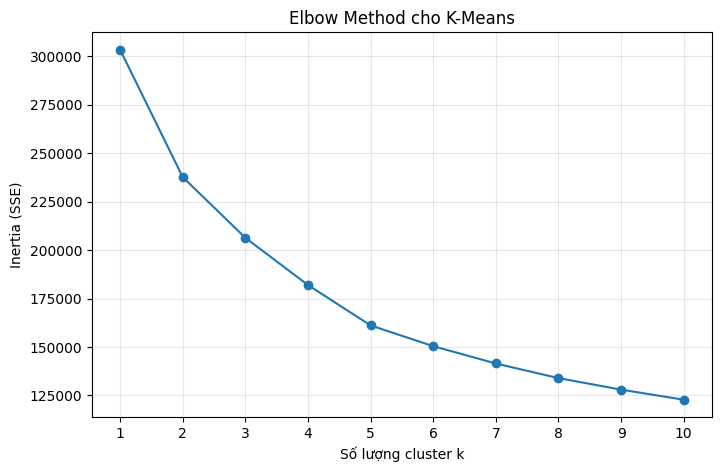

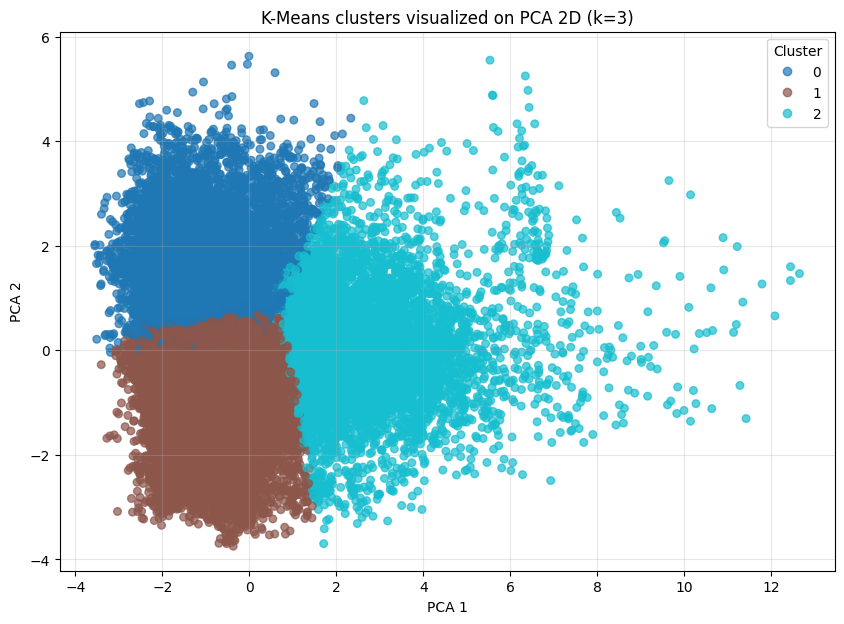

Cluster centroids (original scale):
            aqi      co    no2      o3    pm10   pm25    so2  temperature  relative_humidity  pressure
cluster                                                                                               
0        112.84  169.78  14.07  113.85   51.81  40.12  79.52        29.34              62.24   1007.42
1         95.94  460.00  24.56   39.74   44.90  32.80  45.64        25.21              84.96   1008.21
2        194.06  374.85  47.45   41.31  138.59  99.33  83.52        19.87              76.70   1016.65

Cluster size:
cluster
0     7149
1    15825
2     7367
Name: count, dtype: int64

Mean AQI by cluster:
cluster
0    112.86
1     95.97
2    194.15
Name: aqi, dtype: float64

Cluster distribution by season:
season_name    Hè   Thu  Xuân  Đông
cluster                            
0            2504  2024  1872   749
1            4763  3110  5164  2788
2              77  1419  1799  4072

Cluster distribution by hour:
hour      0    1    2    3    4

In [ ]:
# Phân tích đặc trưng từng cluster
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=X.columns
)
cluster_centers.index.name = 'cluster'
print('Cluster centroids (original scale):')
print(cluster_centers.round(2))

# Cluster profile report
clustered_df = df.loc[X.index].copy()
clustered_df['cluster'] = labels

profile_report = clustered_df.groupby('cluster')[['aqi', 'pm25', 'pm10', 'co', 'no2', 'o3', 'so2', 'temperature', 'relative_humidity', 'pressure']].agg(['count', 'mean', 'std', 'min', 'max'])
print('\nCluster profile report:')
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 200):
    print(profile_report.round(2).to_string())

# Gắn nhãn cluster vào DataFrame gốc để phân tích mùa / giờ
# (tiếp tục phần hiện có)

# Sử dụng cột hour có sẵn nếu có
if 'hour' in clustered_df.columns:
    clustered_df['hour'] = clustered_df['hour']
else:
    if 'date' in clustered_df.columns:
        clustered_df['hour'] = clustered_df['date'].dt.hour


In [8]:
import pandas as pd

# Show full table output instead of truncated notebook display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

if 'season_name' in clustered_df.columns:
    print('\nCluster distribution by season:')
    season_table = clustered_df.groupby(['cluster', 'season_name']).size().unstack(fill_value=0)
    print(season_table.to_string())

if 'hour' in clustered_df.columns:
    print('\nCluster distribution by hour:')
    hour_counts = clustered_df.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
    print(hour_counts.to_string())
    top_hours = hour_counts.idxmax(axis=1)
    print('\nHour with most members in each cluster:')
    print(top_hours.to_string())

if 'aqi' in clustered_df.columns:
    print('\nClusters ranked by mean AQI:')
    print(aqi_cluster.round(2).to_string())



Cluster distribution by season:
season_name    Hè   Thu  Xuân  Đông
cluster                            
0            2504  2024  1872   749
1            4763  3110  5164  2788
2              77  1419  1799  4072

Cluster distribution by hour:
hour      0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23
cluster                                                                                                                        
0         31   27   23   22   23   22   25   29  109  290  474  567  666  764  735  758  796  620  451  302  194  111   68   42
1        865  892  891  875  898  869  865  868  779  620  520  451  392  342  369  351  337  428  520  601  679  753  818  842
2        373  345  350  367  343  373  374  367  376  354  270  246  206  158  160  155  131  216  293  361  391  400  378  380

Hour with most members in each cluster:
cluster
0    16
1     4
2    21

Clusters ranked by mean AQI:
cluster
2    